## 20251009 Only look at O3N2-M13 indicators to check the rMZR and $Z_\mathrm{gas}$-$\Sigma_\mathrm{SFR}$ relation

STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...
  IC3392: HII=14884 pixels
  NGC4064: HII=7067 pixels
  NGC4192: HII=145944 pixels
  NGC4293: HII=5715 pixels
  NGC4298: HII=156350 pixels
  NGC4330: HII=42998 pixels
  NGC4383: excluded from analysis
  NGC4396: HII=81745 pixels
  NGC4419: HII=7354 pixels
  NGC4457: HII=6310 pixels
  NGC4501: HII=261083 pixels
  NGC4522: HII=39665 pixels
  NGC4694: HII=2585 pixels
  NGC4698: HII=10181 pixels

Total combined pixels (HII): 781881

STEP 2: Defining 6 equal-width SFR bins for rMZR

Σ_SFR range:
  Min: -4.567
  Max: 0.019
  Range: 4.586

Bin width: 0.764

6 equal-width SFR bins:
  Bin 1: -4.57–-3.80
  Bin 2: -3.80–-3.04
  Bin 3: -3.04–-2.27
  Bin 4: -2.27–-1.51
  Bin 5: -1.51–-0.75
  Bin 6: -0.75–0.02

STEP 3: Defining 8 Σ_* bins with equal width for Z_gas-Σ_SFR

Σ_* Statistics:
  Min: 5.986
  Max: 9.787
  Range: 3.801
  Bin width: 0.475 dex

8 Σ_* bins (equal width):
  Bin 1: 5.99–6.46
  Bin 2: 6.46–6.94
  Bin 3: 

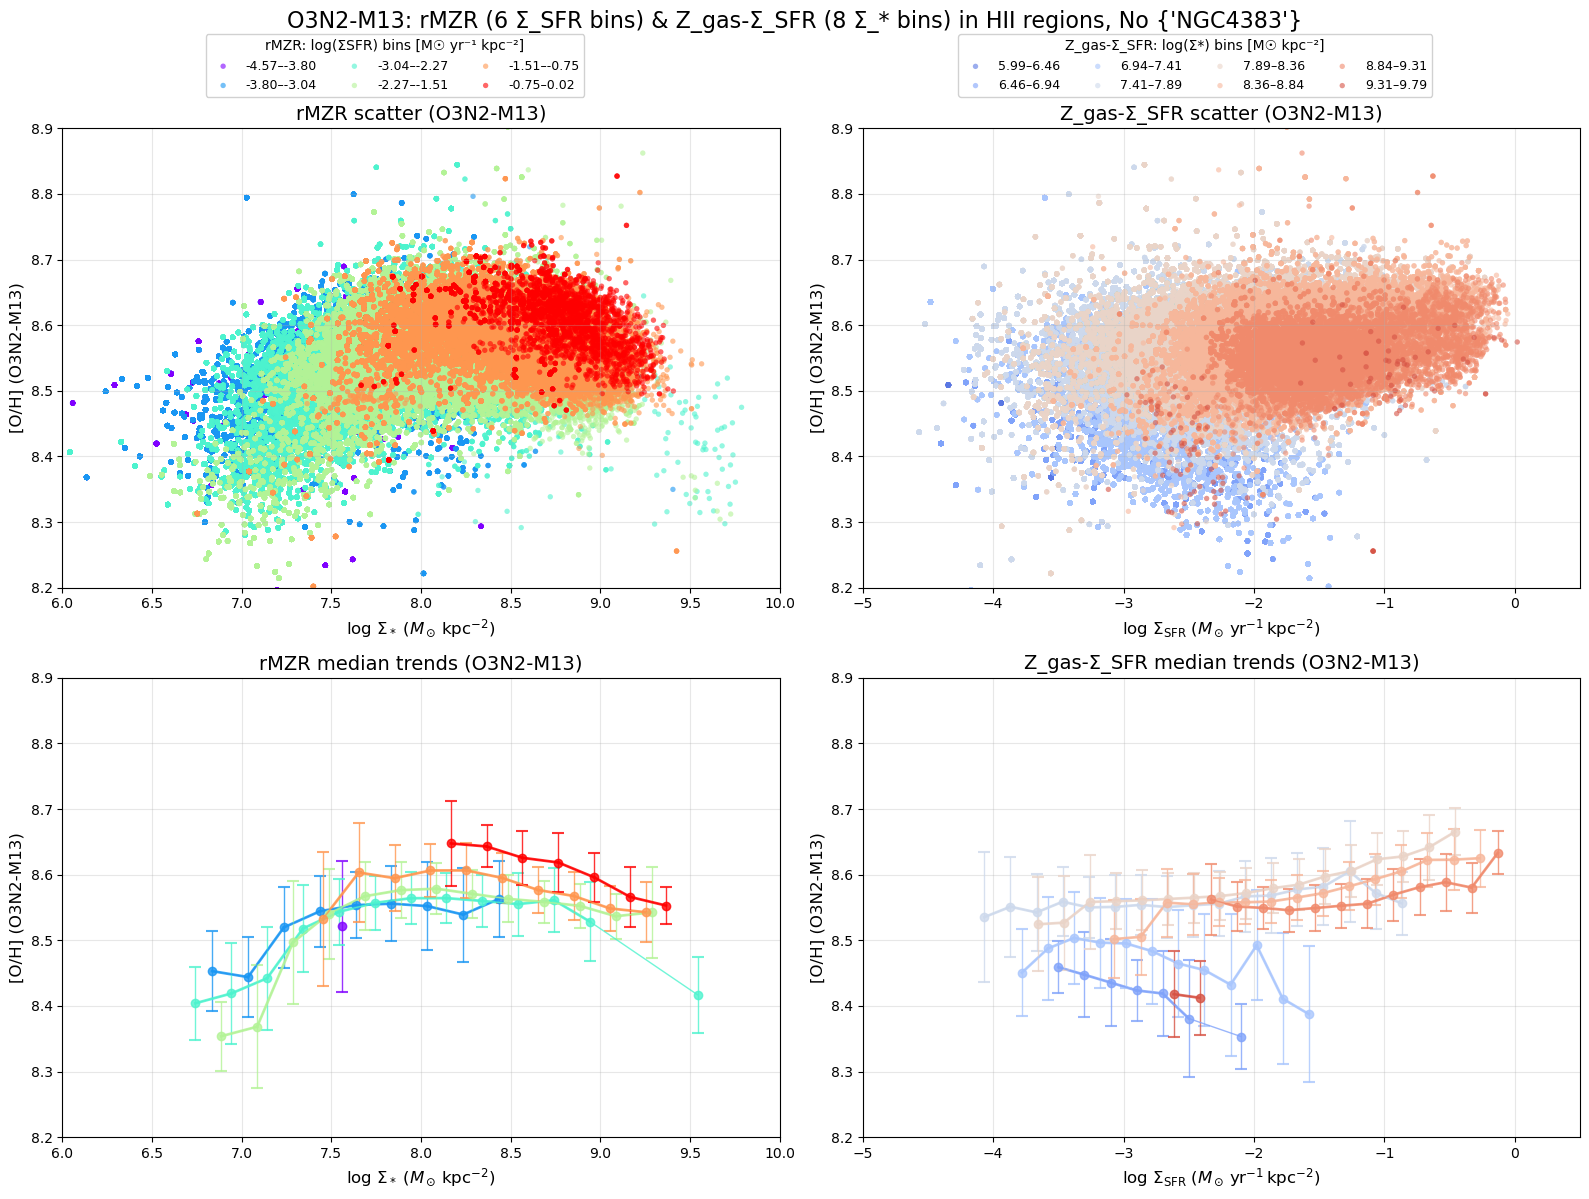


COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)
Successfully created 2x2 subplot figure showing HII regions from 13 galaxies
Galaxies included: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Excluded: NGC4383

Panel summary:
  Top-left: rMZR scatter (6 Σ_SFR bins)
  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins)
  Bottom-left: rMZR median trends (6 Σ_SFR bins)
  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins)
  Shared y-range: 8.2 to 8.9


In [1]:
# ------------------------------------------------------------------
# Combined Analysis: rMZR and Z_gas-Σ_SFR relation - HII regions only
# Using O3N2-M13 indicator only
# 2x2 subplot layout:
#   Top-left: rMZR scatter
#   Top-right: Z_gas-Σ_SFR scatter
#   Bottom-left: rMZR median trends
#   Bottom-right: Z_gas-Σ_SFR median trends
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats

def load_maps_o3n2_m13(gal):
    """Load O3N2-M13 metallicity calibration for HII regions"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        # HII regions
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
    return (sigM, sigSFR_HII, oh_o3n2_m13_HII)

def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_pixels=20):
    """Calculate median and std in bins - only keep bins with >= 20 unique datapoints"""
    # Define bins
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    medians = []
    stds = []
    counts = []
    valid_centers = []
    valid_bin_indices = []
    
    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        # Select data in this bin
        in_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_bin]
        
        if len(np.unique(y_in_bin)) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])
            valid_bin_indices.append(i)
    
    return (np.array(valid_centers), np.array(medians), np.array(stds), 
            np.array(counts), np.array(valid_bin_indices))

# Get all galaxies
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]

# Galaxies to exclude entirely
excluded_galaxies = {'NGC4383'}
included_galaxies = []

# ==============================================================================
# STEP 1: Collect all spaxels from all galaxies for HII regions
# ==============================================================================
all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_o3n2_m13_HII = []

print("="*80)
print("STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...")
print("="*80)

for gal in galaxies:
    if gal in excluded_galaxies:
        print(f"  {gal}: excluded from analysis")
        continue

    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

    if bin_file.exists() and gas_file.exists():
        included_galaxies.append(gal)
        # Load data for HII regions
        (logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII) = load_maps_o3n2_m13(gal)

        # Find common spaxels for HII regions
        common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
                           np.isfinite(oh_o3n2_m13_HII))
        
        print(f"  {gal}: HII={np.sum(common_mask_HII)} pixels")
        
        # Append HII data
        all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
        all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
    else:
        print(f"  {gal}: Data files not found")

# Convert to numpy arrays
all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)

print(f"\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}")

# ==============================================================================
# STEP 2: Define 6 equal-width Σ_SFR bins for rMZR analysis
# ==============================================================================
print("\n" + "="*80)
print("STEP 2: Defining 6 equal-width SFR bins for rMZR")
print("="*80)

# Get SFR range
sfr_min = np.min(all_logSigmaSFR_HII)
sfr_max = np.max(all_logSigmaSFR_HII)
sfr_range = sfr_max - sfr_min

print(f"\nΣ_SFR range:")
print(f"  Min: {sfr_min:.3f}")
print(f"  Max: {sfr_max:.3f}")
print(f"  Range: {sfr_range:.3f}")

# Define 6 bins with equal width
n_bins = 6
bin_width = sfr_range / n_bins

print(f"\nBin width: {bin_width:.3f}")

# Create bin edges
sfr_bin_edges = np.linspace(sfr_min, sfr_max, n_bins + 1)

# Create bin labels
bin_labels = []
for i in range(n_bins):
    bin_labels.append(f'{sfr_bin_edges[i]:.2f}–{sfr_bin_edges[i+1]:.2f}')

print(f"\n6 equal-width SFR bins:")
for i, label in enumerate(bin_labels):
    print(f"  Bin {i+1}: {label}")

# Colors for different bins using rainbow colormap
colors_sfr = plt.cm.rainbow(np.linspace(0, 1, n_bins))

# ==============================================================================
# STEP 3: Define 8 Σ_* bins for Z_gas-Σ_SFR analysis
# ==============================================================================
print("\n" + "="*80)
print("STEP 3: Defining 8 Σ_* bins with equal width for Z_gas-Σ_SFR")
print("="*80)

# Calculate the actual data range
sigmaM_min = np.min(all_logSigmaM_HII)
sigmaM_max = np.max(all_logSigmaM_HII)
sigmaM_range = sigmaM_max - sigmaM_min

print(f"\nΣ_* Statistics:")
print(f"  Min: {sigmaM_min:.3f}")
print(f"  Max: {sigmaM_max:.3f}")
print(f"  Range: {sigmaM_range:.3f}")

# Define 8 Σ_* bins with equal width across the actual data range
n_bins_sigmaM = 8
bin_width_sigmaM = sigmaM_range / n_bins_sigmaM
sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins_sigmaM + 1)

print(f"  Bin width: {bin_width_sigmaM:.3f} dex")

# Create bin labels for Σ_* bins
bin_labels_sigmaM = []
for i in range(n_bins_sigmaM):
    bin_labels_sigmaM.append(f'{sigmaM_bin_edges[i]:.2f}–{sigmaM_bin_edges[i+1]:.2f}')

print(f"\n8 Σ_* bins (equal width):")
for i, label in enumerate(bin_labels_sigmaM):
    print(f"  Bin {i+1}: {label}")

# Colors for 8 Σ_* bins: gradient from blue (low Σ_*) to red (high Σ_*)
colors_sigmaM = plt.cm.coolwarm(np.linspace(0.1, 0.9, n_bins_sigmaM))

# ==============================================================================
# STEP 4: Create combined 2x2 figure (rMZR & Z_gas-Σ_SFR)
# ==============================================================================
print("\n" + "="*80)
print("STEP 4: Creating combined 2x2 plot (O3N2-M13 only)")
print("="*80)

# Set uniform y-axis range
common_ylim = (8.2, 8.9)

print(f"\nUsing uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

# Create figure with 2 rows x 2 columns 
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Use O3N2-M13 data
oh_data_HII = all_oh_o3n2_m13_HII
calib_name_HII = 'O3N2-M13'

print(f"\nProcessing {calib_name_HII} calibration for HII regions:")
print(f"  HII {calib_name_HII} range: {np.min(oh_data_HII):.3f} to {np.max(oh_data_HII):.3f}")

# Assign axes (swap top-right with bottom-left)
ax_rMZR_scatter = axes[0, 0]
ax_Zgas_scatter = axes[0, 1]
ax_rMZR_median = axes[1, 0]
ax_Zgas_median = axes[1, 1]

# =============================================================================
# TOP ROW LEFT: rMZR scatter (in 6 Σ_SFR bins)
# =============================================================================
print(f"\n--- Processing rMZR (6 Σ_SFR bins) ---")

legend_handles_sfr = []
legend_labels_sfr = []

valid_bins_rMZR = 0
for i in range(n_bins):
    # HII regions processing
    if i == 0:
        in_bin_HII = (all_logSigmaSFR_HII >= sfr_bin_edges[i]) & (all_logSigmaSFR_HII < sfr_bin_edges[i+1])
    elif i == n_bins - 1:
        in_bin_HII = (all_logSigmaSFR_HII >= sfr_bin_edges[i]) & (all_logSigmaSFR_HII <= sfr_bin_edges[i+1])
    else:
        in_bin_HII = (all_logSigmaSFR_HII >= sfr_bin_edges[i]) & (all_logSigmaSFR_HII < sfr_bin_edges[i+1])
    
    n_pixels_HII = np.sum(in_bin_HII)
    
    if n_pixels_HII >= 10:
        # Get data for this bin (x=Σ_*, y=[O/H])
        x_bin_HII = all_logSigmaM_HII[in_bin_HII]
        y_bin_HII = oh_data_HII[in_bin_HII]
        
        # Scatter plot
        scatter_hii = ax_rMZR_scatter.scatter(x_bin_HII, y_bin_HII, c=[colors_sfr[i]], s=15, alpha=0.6, 
                             edgecolors='none', rasterized=True)
        
        legend_handles_sfr.append(scatter_hii)
        legend_labels_sfr.append(bin_labels[i])
        
        # Median trends
        mass_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
            x_bin_HII, y_bin_HII, bin_width=0.2, min_pixels=20)
        
        if len(mass_centers_HII) > 0:
            ax_rMZR_median.errorbar(mass_centers_HII, medians_HII, yerr=stds_HII, 
                       color=colors_sfr[i], marker='o', markersize=6, 
                       linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
            
            # Add lines between adjacent bins
            for j in range(len(valid_bin_indices_HII) - 1):
                current_bin_idx = valid_bin_indices_HII[j]
                next_bin_idx = valid_bin_indices_HII[j + 1]
                if next_bin_idx - current_bin_idx == 1:
                    ax_rMZR_median.plot([mass_centers_HII[j], mass_centers_HII[j + 1]], 
                           [medians_HII[j], medians_HII[j + 1]], 
                           color=colors_sfr[i], linewidth=2, alpha=0.8)
            valid_bins_rMZR += 1

# Format rMZR scatter plot
ax_rMZR_scatter.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_rMZR_scatter.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_scatter.set_title(f'rMZR scatter ({calib_name_HII})', fontsize=14)
ax_rMZR_scatter.grid(True, alpha=0.3)
ax_rMZR_scatter.set_xlim(6, 10)
ax_rMZR_scatter.set_ylim(common_ylim)

# =============================================================================
# BOTTOM ROW LEFT: rMZR median trends
# =============================================================================
ax_rMZR_median.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_rMZR_median.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_median.set_title(f'rMZR median trends ({calib_name_HII})', fontsize=14)
ax_rMZR_median.grid(True, alpha=0.3)
ax_rMZR_median.set_xlim(6, 10)
ax_rMZR_median.set_ylim(common_ylim)

print(f"  rMZR valid bins: {valid_bins_rMZR}")

# =============================================================================
# TOP ROW RIGHT: Z_gas-Σ_SFR scatter (in 8 Σ_* bins)
# =============================================================================
print(f"\n--- Processing Z_gas-Σ_SFR (8 Σ_* bins) ---")

legend_handles_sigmaM = []
legend_labels_sigmaM_display = []

valid_bins_Zgas = 0
for i in range(n_bins_sigmaM):
    # HII regions processing
    if i == 0:
        in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i+1])
    elif i == n_bins_sigmaM - 1:
        in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII <= sigmaM_bin_edges[i+1])
    else:
        in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i+1])
    
    n_pixels_HII = np.sum(in_bin_HII)
    
    if n_pixels_HII >= 10:
        # Get data for this bin (x=Σ_SFR, y=[O/H])
        x_bin_HII = all_logSigmaSFR_HII[in_bin_HII]
        y_bin_HII = oh_data_HII[in_bin_HII]
        
        # Scatter plot
        scatter_hii = ax_Zgas_scatter.scatter(x_bin_HII, y_bin_HII, c=[colors_sigmaM[i]], s=15, alpha=0.6, 
                             edgecolors='none', rasterized=True)
        
        legend_handles_sigmaM.append(scatter_hii)
        legend_labels_sigmaM_display.append(bin_labels_sigmaM[i])
        
        # Median trends (now bin by Σ_SFR)
        sfr_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
            x_bin_HII, y_bin_HII, bin_width=0.2, min_pixels=20)
        
        if len(sfr_centers_HII) > 0:
            ax_Zgas_median.errorbar(sfr_centers_HII, medians_HII, yerr=stds_HII, 
                       color=colors_sigmaM[i], marker='o', markersize=6, 
                       linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
            
            # Add lines between adjacent bins
            for j in range(len(valid_bin_indices_HII) - 1):
                current_bin_idx = valid_bin_indices_HII[j]
                next_bin_idx = valid_bin_indices_HII[j + 1]
                if next_bin_idx - current_bin_idx == 1:
                    ax_Zgas_median.plot([sfr_centers_HII[j], sfr_centers_HII[j + 1]], 
                           [medians_HII[j], medians_HII[j + 1]], 
                           color=colors_sigmaM[i], linewidth=2, alpha=0.8)
            valid_bins_Zgas += 1

# Format Z_gas-Σ_SFR scatter plot
ax_Zgas_scatter.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_Zgas_scatter.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_Zgas_scatter.set_title(f'Z_gas-Σ_SFR scatter ({calib_name_HII})', fontsize=14)
ax_Zgas_scatter.grid(True, alpha=0.3)
ax_Zgas_scatter.set_xlim(-5.0, 0.5)
ax_Zgas_scatter.set_ylim(common_ylim)

# =============================================================================
# BOTTOM ROW RIGHT: Z_gas-Σ_SFR median trends
# =============================================================================
ax_Zgas_median.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_Zgas_median.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_Zgas_median.set_title(f'Z_gas-Σ_SFR median trends ({calib_name_HII})', fontsize=14)
ax_Zgas_median.grid(True, alpha=0.3)
ax_Zgas_median.set_xlim(-5.0, 0.5)
ax_Zgas_median.set_ylim(common_ylim)

print(f"  Z_gas-Σ_SFR valid bins: {valid_bins_Zgas}")

# Add overall title
fig.suptitle(f'{calib_name_HII}: rMZR (6 Σ_SFR bins) & Z_gas-Σ_SFR (8 Σ_* bins) in HII regions, No {excluded_galaxies}', 
             fontsize=16, y=0.995)

# Add legends - one for each row (positions unchanged)
legend1 = fig.legend(legend_handles_sfr, legend_labels_sfr, loc='upper center', 
                    bbox_to_anchor=(0.25, 0.98), ncol=3, fontsize=9, framealpha=0.9,
                    title='rMZR: log(ΣSFR) bins [M☉ yr⁻¹ kpc⁻²]', title_fontsize=10)
legend2 = fig.legend(legend_handles_sigmaM, legend_labels_sigmaM_display, loc='upper center', 
                    bbox_to_anchor=(0.75, 0.98), ncol=4, fontsize=9, framealpha=0.9,
                    title='Z_gas-Σ_SFR: log(Σ*) bins [M☉ kpc⁻²]', title_fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.96])
# plt.savefig('Combined_rMZR_Zgas_SigmaSFR_O3N2M13_2x2.png', dpi=300, bbox_inches='tight')
# plt.savefig('Combined_rMZR_Zgas_SigmaSFR_O3N2M13_2x2.pdf', bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)")
print("="*80)
print(f"Successfully created 2x2 subplot figure showing HII regions from {len(included_galaxies)} galaxies")
print(f"Galaxies included: {', '.join(included_galaxies)}")
print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")
print("\nPanel summary:")
print("  Top-left: rMZR scatter (6 Σ_SFR bins)")
print("  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins)")
print("  Bottom-left: rMZR median trends (6 Σ_SFR bins)")
print("  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins)")
print(f"  Shared y-range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")


STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...
  IC3392: HII=14884 pixels
  NGC4064: HII=7067 pixels
  NGC4192: HII=145944 pixels
  NGC4293: HII=5715 pixels
  NGC4298: HII=156350 pixels
  NGC4330: HII=42998 pixels
  NGC4383: excluded from analysis
  NGC4396: HII=81745 pixels
  NGC4419: HII=7354 pixels
  NGC4457: HII=6310 pixels
  NGC4501: HII=261083 pixels
  NGC4522: HII=39665 pixels
  NGC4694: HII=2585 pixels
  NGC4698: HII=10181 pixels

Total combined pixels (HII): 781881
NGC4192 pixels (HII): 145944

STEP 2: Defining 6 equal-width SFR bins for rMZR (NGC4192 range)

Σ_SFR range (NGC4192):
  Min: -3.960
  Max: -0.069
  Range: 3.891

Bin width: 0.648

6 equal-width SFR bins (NGC4192):
  Bin 1: -3.96–-3.31
  Bin 2: -3.31–-2.66
  Bin 3: -2.66–-2.01
  Bin 4: -2.01–-1.37
  Bin 5: -1.37–-0.72
  Bin 6: -0.72–-0.07

STEP 3: Defining 8 Σ_* bins with equal width for Z_gas-Σ_SFR (NGC4192 range)

Σ_* Statistics (NGC4192):
  Min: 6.797
  Max: 9.564
  Range: 2.767
  Bi

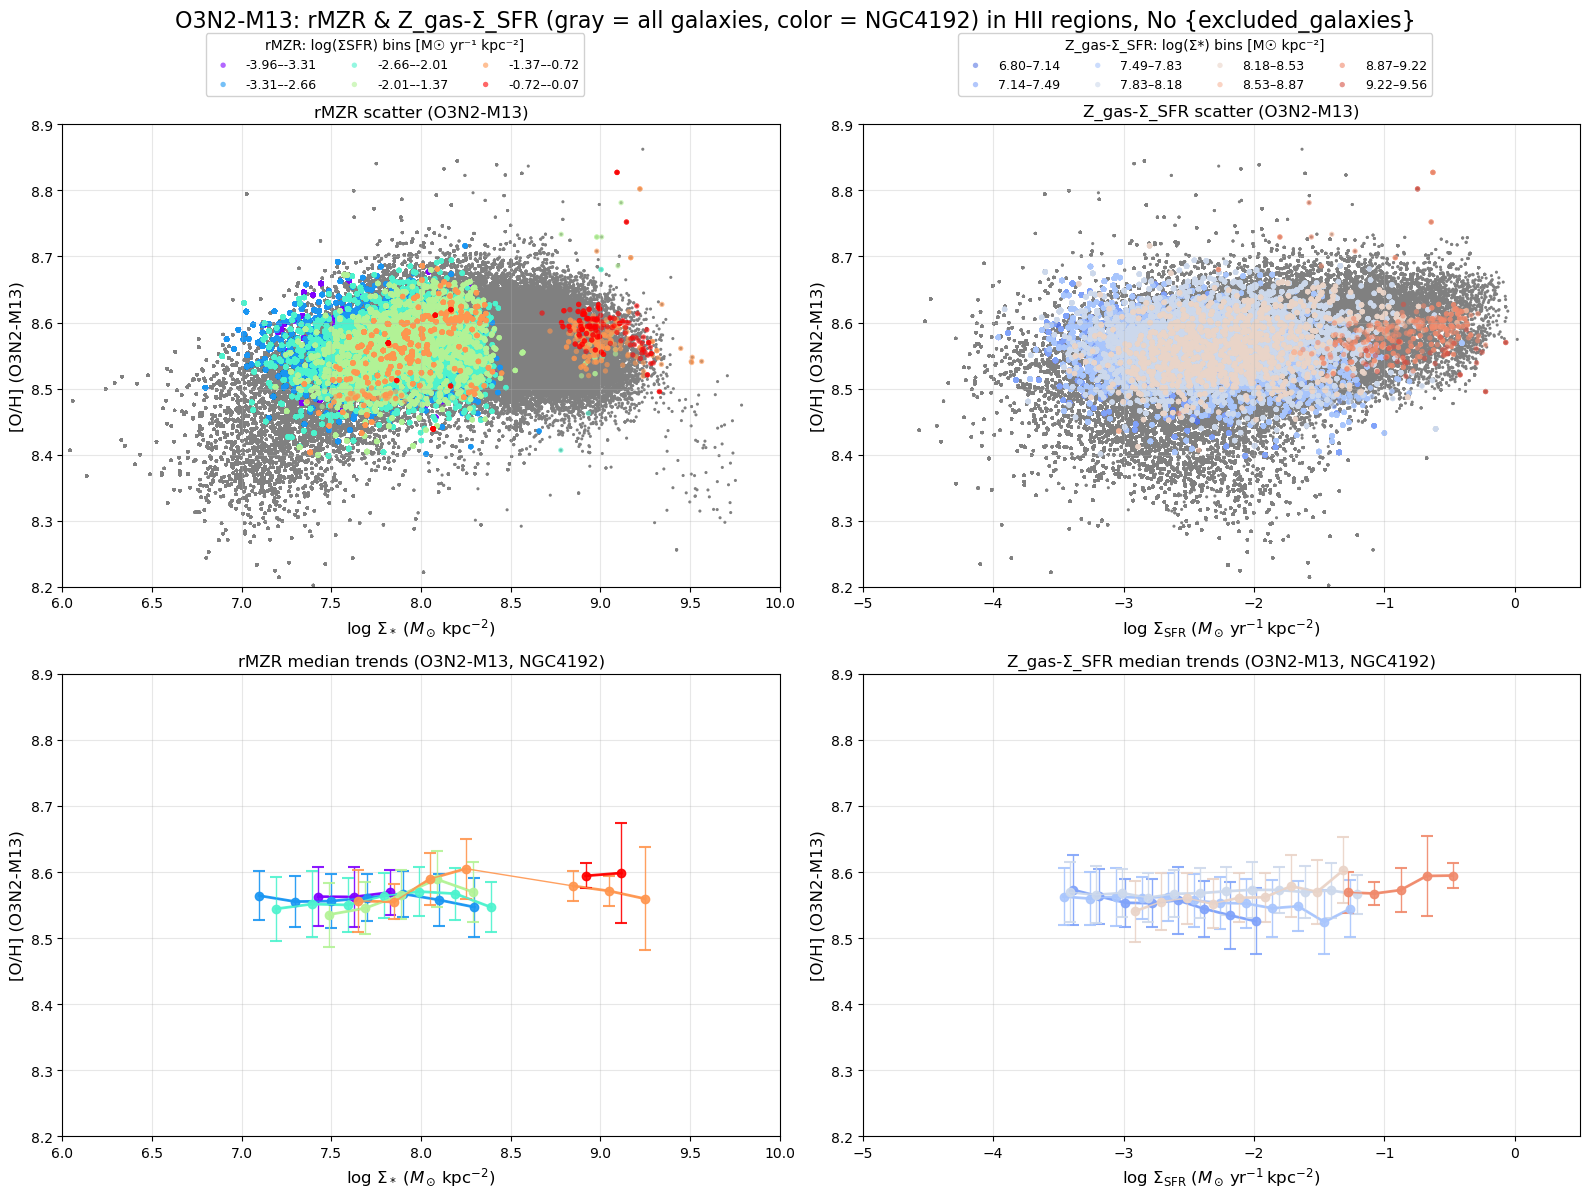


COMPLETED: NGC4192-highlighted rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)
Successfully created 2x2 subplot figure with all-galaxy background and NGC4192 highlight from 13 galaxies
Galaxies included (background): IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Excluded: NGC4383

Panel summary:
  Top-left: rMZR scatter (gray = all, color = NGC4192 by Σ_SFR bin)
  Top-right: Z_gas-Σ_SFR scatter (gray = all, color = NGC4192 by Σ_* bin)
  Bottom-left: rMZR median trends (NGC4192)
  Bottom-right: Z_gas-Σ_SFR median trends (NGC4192)
  Shared y-range: 8.2 to 8.9


In [2]:
# ------------------------------------------------------------------
# Combined Analysis with NGC4192 highlight: rMZR and Z_gas-Σ_SFR relation - HII regions only
# Using O3N2-M13 indicator only
# 2x2 subplot layout:
#   Top-left: rMZR scatter (gray background = all galaxies, color = NGC4192)
#   Top-right: Z_gas-Σ_SFR scatter (gray background = all galaxies, color = NGC4192)
#   Bottom-left: rMZR median trends (NGC4192)
#   Bottom-right: Z_gas-Σ_SFR median trends (NGC4192)
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats

def load_maps_o3n2_m13(gal):
    """Load O3N2-M13 metallicity calibration for HII regions"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        # HII regions
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
    return (sigM, sigSFR_HII, oh_o3n2_m13_HII)

def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_pixels=20):
    """Calculate median and std in bins - only keep bins with >= 20 unique datapoints"""
    # Define bins
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    if np.isinf(x_min) or np.isinf(x_max):
        return (np.array([]), np.array([]), np.array([]), np.array([]), np.array([]))
    if np.isnan(x_min) or np.isnan(x_max):
        return (np.array([]), np.array([]), np.array([]), np.array([]), np.array([]))
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    if len(bin_edges) < 2:
        return (np.array([]), np.array([]), np.array([]), np.array([]), np.array([]))
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    medians = []
    stds = []
    counts = []
    valid_centers = []
    valid_bin_indices = []
    
    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        # Select data in this bin
        in_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_bin]
        
        if len(np.unique(y_in_bin)) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])
            valid_bin_indices.append(i)
    
    return (np.array(valid_centers), np.array(medians), np.array(stds), 
            np.array(counts), np.array(valid_bin_indices))

# Get all galaxies
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]

# Galaxies to exclude entirely
excluded_galaxies = {'NGC4383'}
included_galaxies = []

# ==============================================================================
# STEP 1: Collect all spaxels from all galaxies & isolate NGC4192
# ==============================================================================
all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_o3n2_m13_HII = []

ngc4192_logSigmaM_HII = []
ngc4192_logSigmaSFR_HII = []
ngc4192_oh_o3n2_m13_HII = []

print("="*80)
print("STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...")
print("="*80)

for gal in galaxies:
    if gal in excluded_galaxies:
        print(f"  {gal}: excluded from analysis")
        continue

    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

    if bin_file.exists() and gas_file.exists():
        included_galaxies.append(gal)
        # Load data for HII regions
        (logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII) = load_maps_o3n2_m13(gal)

        # Find common spaxels for HII regions
        common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
                           np.isfinite(oh_o3n2_m13_HII))
        
        print(f"  {gal}: HII={np.sum(common_mask_HII)} pixels")
        
        # Append HII data (combined background)
        all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
        all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())

        # Store NGC4192 data separately
        if gal == 'NGC4192':
            ngc4192_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
            ngc4192_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
            ngc4192_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
    else:
        print(f"  {gal}: Data files not found")

# Convert to numpy arrays
all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)

ngc4192_logSigmaM_HII = np.array(ngc4192_logSigmaM_HII)
ngc4192_logSigmaSFR_HII = np.array(ngc4192_logSigmaSFR_HII)
ngc4192_oh_o3n2_m13_HII = np.array(ngc4192_oh_o3n2_m13_HII)

print(f"\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}")
print(f"NGC4192 pixels (HII): {len(ngc4192_logSigmaM_HII)}")

if len(ngc4192_logSigmaM_HII) == 0:
    raise ValueError("No valid NGC4192 pixels found. Cannot proceed with NGC4192-highlight plots.")

# ==============================================================================
# STEP 2: Define 6 equal-width Σ_SFR bins for rMZR analysis (based on NGC4192)
# ==============================================================================
print("\n" + "="*80)
print("STEP 2: Defining 6 equal-width SFR bins for rMZR (NGC4192 range)")
print("="*80)

# Get SFR range (NGC4192)
sfr_min = np.min(ngc4192_logSigmaSFR_HII)
sfr_max = np.max(ngc4192_logSigmaSFR_HII)
sfr_range = sfr_max - sfr_min

print(f"\nΣ_SFR range (NGC4192):")
print(f"  Min: {sfr_min:.3f}")
print(f"  Max: {sfr_max:.3f}")
print(f"  Range: {sfr_range:.3f}")

# Define 6 bins with equal width (NGC4192)
n_bins = 6
bin_width = sfr_range / n_bins if n_bins > 0 else np.nan

print(f"\nBin width: {bin_width:.3f}")

# Create bin edges (NGC4192)
sfr_bin_edges = np.linspace(sfr_min, sfr_max, n_bins + 1)

# Create bin labels
bin_labels = []
for i in range(n_bins):
    bin_labels.append(f'{sfr_bin_edges[i]:.2f}–{sfr_bin_edges[i+1]:.2f}')

print(f"\n6 equal-width SFR bins (NGC4192):")
for i, label in enumerate(bin_labels):
    print(f"  Bin {i+1}: {label}")

# Colors for different bins using rainbow colormap
colors_sfr = plt.cm.rainbow(np.linspace(0, 1, n_bins))

# ==============================================================================
# STEP 3: Define 8 Σ_* bins for Z_gas-Σ_SFR analysis (based on NGC4192)
# ==============================================================================
print("\n" + "="*80)
print("STEP 3: Defining 8 Σ_* bins with equal width for Z_gas-Σ_SFR (NGC4192 range)")
print("="*80)

# Calculate the actual data range (NGC4192)
sigmaM_min = np.min(ngc4192_logSigmaM_HII)
sigmaM_max = np.max(ngc4192_logSigmaM_HII)
sigmaM_range = sigmaM_max - sigmaM_min

print(f"\nΣ_* Statistics (NGC4192):")
print(f"  Min: {sigmaM_min:.3f}")
print(f"  Max: {sigmaM_max:.3f}")
print(f"  Range: {sigmaM_range:.3f}")

# Define 8 Σ_* bins with equal width across the NGC4192 data range
n_bins_sigmaM = 8
bin_width_sigmaM = sigmaM_range / n_bins_sigmaM if n_bins_sigmaM > 0 else np.nan
sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins_sigmaM + 1)

print(f"  Bin width: {bin_width_sigmaM:.3f} dex")

# Create bin labels for Σ_* bins
bin_labels_sigmaM = []
for i in range(n_bins_sigmaM):
    bin_labels_sigmaM.append(f'{sigmaM_bin_edges[i]:.2f}–{sigmaM_bin_edges[i+1]:.2f}')

print(f"\n8 Σ_* bins (NGC4192):")
for i, label in enumerate(bin_labels_sigmaM):
    print(f"  Bin {i+1}: {label}")

# Colors for 8 Σ_* bins: gradient from blue (low Σ_*) to red (high Σ_*)
colors_sigmaM = plt.cm.coolwarm(np.linspace(0.1, 0.9, n_bins_sigmaM))

# ==============================================================================
# STEP 4: Create combined 2x2 figure (background = all, highlight = NGC4192)
# ==============================================================================
print("\n" + "="*80)
print("STEP 4: Creating combined 2x2 plot highlighting NGC4192")
print("="*80)

# Set uniform y-axis range
common_ylim = (8.2, 8.9)

print(f"\nUsing uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

# Create figure with 2 rows x 2 columns 
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Assign axes (swap top-right with bottom-left for layout)
ax_rMZR_scatter = axes[0, 0]
ax_Zgas_scatter = axes[0, 1]
ax_rMZR_median = axes[1, 0]
ax_Zgas_median = axes[1, 1]

# =============================================================================
# TOP ROW LEFT: rMZR scatter (gray background = all, color-coded = NGC4192)
# =============================================================================
print(f"\n--- Processing rMZR (6 Σ_SFR bins) ---")

# Background scatter for all galaxies
ax_rMZR_scatter.scatter(all_logSigmaM_HII, all_oh_o3n2_m13_HII, c='gray', s=5, alpha=1.0,
                        edgecolors='none', rasterized=True)

legend_handles_sfr = []
legend_labels_sfr = []

valid_bins_rMZR = 0
for i in range(n_bins):
    # NGC4192 binning in Σ_SFR
    if i == 0:
        in_bin_ngc4192 = (ngc4192_logSigmaSFR_HII >= sfr_bin_edges[i]) & (ngc4192_logSigmaSFR_HII < sfr_bin_edges[i+1])
    elif i == n_bins - 1:
        in_bin_ngc4192 = (ngc4192_logSigmaSFR_HII >= sfr_bin_edges[i]) & (ngc4192_logSigmaSFR_HII <= sfr_bin_edges[i+1])
    else:
        in_bin_ngc4192 = (ngc4192_logSigmaSFR_HII >= sfr_bin_edges[i]) & (ngc4192_logSigmaSFR_HII < sfr_bin_edges[i+1])
    
    n_pixels_ngc4192 = np.sum(in_bin_ngc4192)
    
    if n_pixels_ngc4192 >= 10:
        # NGC4192 data for this bin (x=Σ_*, y=[O/H])
        x_bin_ngc4192 = ngc4192_logSigmaM_HII[in_bin_ngc4192]
        y_bin_ngc4192 = ngc4192_oh_o3n2_m13_HII[in_bin_ngc4192]
        
        # Scatter plot (NGC4192 highlight)
        scatter_hii = ax_rMZR_scatter.scatter(x_bin_ngc4192, y_bin_ngc4192, c=[colors_sfr[i]], s=15, alpha=0.6, 
                             edgecolors='none', rasterized=True)
        legend_handles_sfr.append(scatter_hii)
        legend_labels_sfr.append(bin_labels[i])
        
        # Median trends (NGC4192 only)
        mass_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
            x_bin_ngc4192, y_bin_ngc4192, bin_width=0.2, min_pixels=20)
        
        if len(mass_centers_HII) > 0:
            ax_rMZR_median.errorbar(mass_centers_HII, medians_HII, yerr=stds_HII, 
                                    color=colors_sfr[i], marker='o', markersize=6, 
                                    linewidth=1, capsize=4, capthick=1.5, alpha=0.9)
            
            # Add lines between adjacent bins
            for j in range(len(valid_bin_indices_HII) - 1):
                current_bin_idx = valid_bin_indices_HII[j]
                next_bin_idx = valid_bin_indices_HII[j + 1]
                if next_bin_idx - current_bin_idx == 1:
                    ax_rMZR_median.plot([mass_centers_HII[j], mass_centers_HII[j + 1]], 
                                        [medians_HII[j], medians_HII[j + 1]], 
                                        color=colors_sfr[i], linewidth=2, alpha=0.9)
            valid_bins_rMZR += 1

# Format rMZR scatter plot
ax_rMZR_scatter.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_rMZR_scatter.set_ylabel(f'[O/H] (O3N2-M13)', fontsize=12)
ax_rMZR_scatter.set_title('rMZR scatter (O3N2-M13)')
ax_rMZR_scatter.grid(True, alpha=0.3)
ax_rMZR_scatter.set_xlim(6, 10)
ax_rMZR_scatter.set_ylim(common_ylim)

# =============================================================================
# BOTTOM ROW LEFT: rMZR median trends (NGC4192)
# =============================================================================
ax_rMZR_median.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_rMZR_median.set_ylabel(f'[O/H] (O3N2-M13)', fontsize=12)
ax_rMZR_median.set_title('rMZR median trends (O3N2-M13, NGC4192)')
ax_rMZR_median.grid(True, alpha=0.3)
ax_rMZR_median.set_xlim(6, 10)
ax_rMZR_median.set_ylim(common_ylim)

print(f"  rMZR valid bins (NGC4192): {valid_bins_rMZR}")

# =============================================================================
# TOP ROW RIGHT: Z_gas-Σ_SFR scatter (gray background = all, color-coded = NGC4192)
# =============================================================================
print(f"\n--- Processing Z_gas-Σ_SFR (8 Σ_* bins) ---")

# Background scatter for all galaxies
ax_Zgas_scatter.scatter(all_logSigmaSFR_HII, all_oh_o3n2_m13_HII, c='gray', s=5, alpha=1.0,
                        edgecolors='none', rasterized=True)

legend_handles_sigmaM = []
legend_labels_sigmaM_display = []

valid_bins_Zgas = 0
for i in range(n_bins_sigmaM):
    # NGC4192 binning in Σ_*
    if i == 0:
        in_bin_ngc4192 = (ngc4192_logSigmaM_HII >= sigmaM_bin_edges[i]) & (ngc4192_logSigmaM_HII < sigmaM_bin_edges[i+1])
    elif i == n_bins_sigmaM - 1:
        in_bin_ngc4192 = (ngc4192_logSigmaM_HII >= sigmaM_bin_edges[i]) & (ngc4192_logSigmaM_HII <= sigmaM_bin_edges[i+1])
    else:
        in_bin_ngc4192 = (ngc4192_logSigmaM_HII >= sigmaM_bin_edges[i]) & (ngc4192_logSigmaM_HII < sigmaM_bin_edges[i+1])
    
    n_pixels_ngc4192 = np.sum(in_bin_ngc4192)
    
    if n_pixels_ngc4192 >= 10:
        # NGC4192 data for this bin (x=Σ_SFR, y=[O/H])
        x_bin_ngc4192 = ngc4192_logSigmaSFR_HII[in_bin_ngc4192]
        y_bin_ngc4192 = ngc4192_oh_o3n2_m13_HII[in_bin_ngc4192]
        
        # Scatter plot (NGC4192 highlight)
        scatter_hii = ax_Zgas_scatter.scatter(x_bin_ngc4192, y_bin_ngc4192, c=[colors_sigmaM[i]], s=15, alpha=0.6, 
                             edgecolors='none', rasterized=True)
        legend_handles_sigmaM.append(scatter_hii)
        legend_labels_sigmaM_display.append(bin_labels_sigmaM[i])
        
        # Median trends (NGC4192 only)
        sfr_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
            x_bin_ngc4192, y_bin_ngc4192, bin_width=0.2, min_pixels=20)
        
        if len(sfr_centers_HII) > 0:
            ax_Zgas_median.errorbar(sfr_centers_HII, medians_HII, yerr=stds_HII, 
                                    color=colors_sigmaM[i], marker='o', markersize=6, 
                                    linewidth=1, capsize=4, capthick=1.5, alpha=0.9)
            
            # Add lines between adjacent bins
            for j in range(len(valid_bin_indices_HII) - 1):
                current_bin_idx = valid_bin_indices_HII[j]
                next_bin_idx = valid_bin_indices_HII[j + 1]
                if next_bin_idx - current_bin_idx == 1:
                    ax_Zgas_median.plot([sfr_centers_HII[j], sfr_centers_HII[j + 1]], 
                                        [medians_HII[j], medians_HII[j + 1]], 
                                        color=colors_sigmaM[i], linewidth=2, alpha=0.9)
            valid_bins_Zgas += 1

# Format Z_gas-Σ_SFR scatter plot
ax_Zgas_scatter.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_Zgas_scatter.set_ylabel(f'[O/H] (O3N2-M13)', fontsize=12)
ax_Zgas_scatter.set_title('Z_gas-Σ_SFR scatter (O3N2-M13)')
ax_Zgas_scatter.grid(True, alpha=0.3)
ax_Zgas_scatter.set_xlim(-5.0, 0.5)
ax_Zgas_scatter.set_ylim(common_ylim)

# =============================================================================
# BOTTOM ROW RIGHT: Z_gas-Σ_SFR median trends (NGC4192)
# =============================================================================
ax_Zgas_median.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_Zgas_median.set_ylabel(f'[O/H] (O3N2-M13)', fontsize=12)
ax_Zgas_median.set_title('Z_gas-Σ_SFR median trends (O3N2-M13, NGC4192)')
ax_Zgas_median.grid(True, alpha=0.3)
ax_Zgas_median.set_xlim(-5.0, 0.5)
ax_Zgas_median.set_ylim(common_ylim)

print(f"  Z_gas-Σ_SFR valid bins (NGC4192): {valid_bins_Zgas}")

# Add overall title
fig.suptitle('O3N2-M13: rMZR & Z_gas-Σ_SFR (gray = all galaxies, color = NGC4192) in HII regions, No {excluded_galaxies}', fontsize=16, y=0.995)

# Add legends - one for each row (positions unchanged)
legend1 = fig.legend(legend_handles_sfr, legend_labels_sfr, loc='upper center', 
                    bbox_to_anchor=(0.25, 0.98), ncol=3, fontsize=9, framealpha=0.9,
                    title='rMZR: log(ΣSFR) bins [M☉ yr⁻¹ kpc⁻²]', title_fontsize=10)
legend2 = fig.legend(legend_handles_sigmaM, legend_labels_sigmaM_display, loc='upper center', 
                    bbox_to_anchor=(0.75, 0.98), ncol=4, fontsize=9, framealpha=0.9,
                    title='Z_gas-Σ_SFR: log(Σ*) bins [M☉ kpc⁻²]', title_fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.96])
# plt.savefig('NGC4192_rMZR_Zgas_SigmaSFR_O3N2M13_2x2.png', dpi=300, bbox_inches='tight')
# plt.savefig('NGC4192_rMZR_Zgas_SigmaSFR_O3N2M13_2x2.pdf', bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("COMPLETED: NGC4192-highlighted rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)")
print("="*80)
print(f"Successfully created 2x2 subplot figure with all-galaxy background and NGC4192 highlight from {len(included_galaxies)} galaxies")
print(f"Galaxies included (background): {', '.join(included_galaxies)}")
print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")
print("\nPanel summary:")
print("  Top-left: rMZR scatter (gray = all, color = NGC4192 by Σ_SFR bin)")
print("  Top-right: Z_gas-Σ_SFR scatter (gray = all, color = NGC4192 by Σ_* bin)")
print("  Bottom-left: rMZR median trends (NGC4192)")
print("  Bottom-right: Z_gas-Σ_SFR median trends (NGC4192)")
print(f"  Shared y-range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")



[O3N2-M13] [O/H] statistics by metallicity bin for NGC4192:
  Bin 1 (8.398 to 8.485): 6938 pixels, median [O/H] = 8.465
  Bin 2 (8.485 to 8.571): 84675 pixels, median [O/H] = 8.544
  Bin 3 (8.571 to 8.658): 53135 pixels, median [O/H] = 8.592
  Bin 4 (8.658 to 8.745): 1186 pixels, median [O/H] = 8.667
  Bin 5 (8.745 to 8.832): 8 pixels, median [O/H] = 8.802
  Bin 6 (8.832 to 8.918): 2 pixels, median [O/H] = 8.918


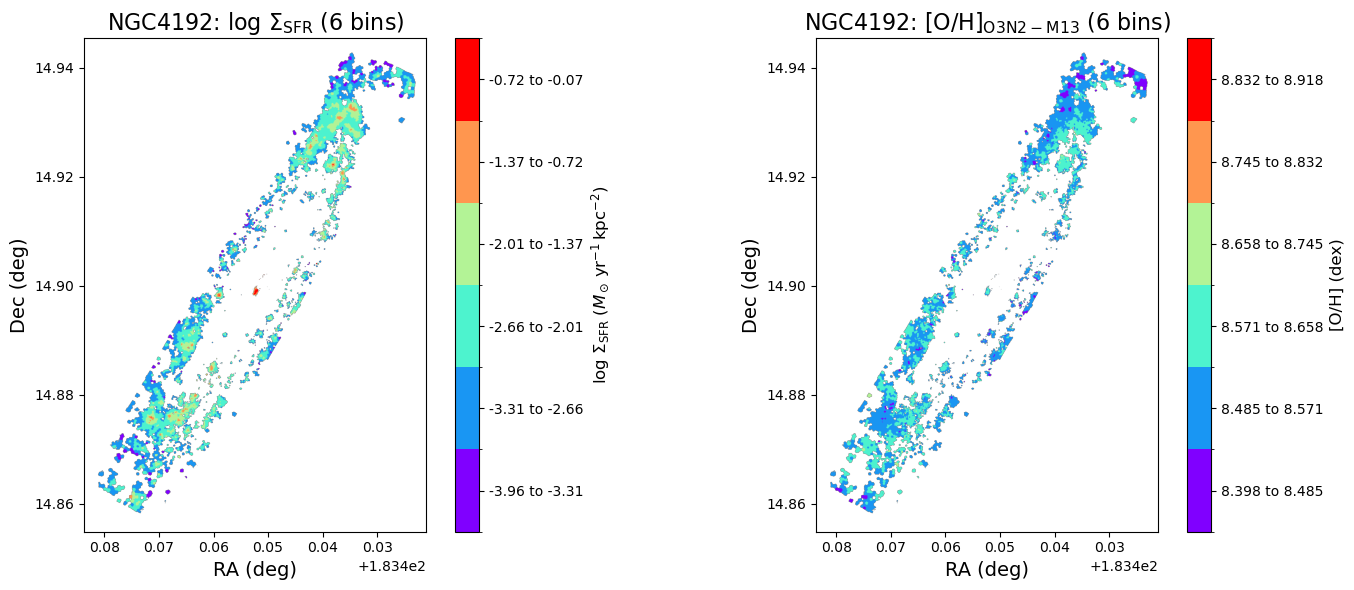

In [3]:
# ------------------------------------------------------------------
# 0.  Load NGC4192 maps and visualise Σ_SFR bins (6) + [O/H] bins (6, rainbow)
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# Only focus on NGC4192 for this visualisation
galaxies = ['NGC4192']

# ------------------------------------------------------------------
# 1.  Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    return sigM, sigSFR, oh_map, indicator_name, wcs, gas_header

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name, wcs_full, gas_header = load_maps(gal)

    # Valid pixels across maps
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_all = valid_sfr & valid_oh

    # ------------------------------------------------------------------
    # 2.  Define bin edges (match those used earlier in this notebook)
    # ------------------------------------------------------------------
    # Σ_SFR bins (6)
    n_sfr_bins = 6
    sfr_min, sfr_max = np.nanmin(sigSFR[valid_sfr]), np.nanmax(sigSFR[valid_sfr])
    sfr_bin_edges = np.linspace(sfr_min, sfr_max, n_sfr_bins + 1)
    colors_sfr = plt.cm.rainbow(np.linspace(0, 1, n_sfr_bins))

    # Metallicities bins (6 equal width, rainbow palette)
    n_oh_bins = 6
    oh_min, oh_max = np.nanmin(oh_o3n2_map[valid_oh]), np.nanmax(oh_o3n2_map[valid_oh])
    oh_bin_edges = np.linspace(oh_min, oh_max, n_oh_bins + 1)
    colors_oh = plt.cm.rainbow(np.linspace(0, 1, n_oh_bins))

    # ------------------------------------------------------------------
    # 3.  Prepare coordinate extent for plotting (RA/Dec degrees)
    # ------------------------------------------------------------------
    wcs_celestial = WCS(gas_header).celestial
    y_size, x_size = sigSFR.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]

    # ------------------------------------------------------------------
    # 4.  Build discrete maps for Σ_SFR bins (left) and [O/H] bins (right)
    # ------------------------------------------------------------------
    sfr_bin_map = np.full(sigSFR.shape, np.nan)
    oh_bin_map = np.full(oh_o3n2_map.shape, np.nan)

    for i in range(n_sfr_bins):
        lower, upper = sfr_bin_edges[i], sfr_bin_edges[i + 1]
        if i == n_sfr_bins - 1:
            mask = valid_sfr & (sigSFR >= lower) & (sigSFR <= upper)
        else:
            mask = valid_sfr & (sigSFR >= lower) & (sigSFR < upper)
        sfr_bin_map[mask] = i

    for i in range(n_oh_bins):
        lower, upper = oh_bin_edges[i], oh_bin_edges[i + 1]
        if i == n_oh_bins - 1:
            mask = valid_oh & (oh_o3n2_map >= lower) & (oh_o3n2_map <= upper)
        else:
            mask = valid_oh & (oh_o3n2_map >= lower) & (oh_o3n2_map < upper)
        oh_bin_map[mask] = i

    # ------------------------------------------------------------------
    # 5.  Create figure: left = Σ_SFR bins, right = [O/H] bins (rainbow)
    # ------------------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Left-hand side: Σ_SFR bin map
    sfr_cmap = ListedColormap(colors_sfr)
    sfr_norm = BoundaryNorm(np.arange(-0.5, n_sfr_bins + 0.5, 1), n_sfr_bins)
    im_sfr = axes[0].imshow(np.ma.masked_invalid(sfr_bin_map), origin='lower', cmap=sfr_cmap,
                            norm=sfr_norm, extent=extent)
    axes[0].set_title(rf'{gal}: $\log\,\Sigma_{{\mathrm{{SFR}}}}$ (6 bins)', fontsize=16)
    axes[0].set_xlabel('RA (deg)', fontsize=14)
    axes[0].set_ylabel('Dec (deg)', fontsize=14)

    cbar_sfr = fig.colorbar(im_sfr, ax=axes[0], fraction=0.046, pad=0.04)
    cbar_sfr.set_label(r'$\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
    sfr_tick_positions = np.arange(n_sfr_bins)
    sfr_tick_labels = [f'{sfr_bin_edges[i]:.2f} to {sfr_bin_edges[i+1]:.2f}' for i in range(n_sfr_bins)]
    cbar_sfr.set_ticks(sfr_tick_positions)
    cbar_sfr.set_ticklabels(sfr_tick_labels)

    # Right-hand side: [O/H] bin map (rainbow)
    oh_cmap = ListedColormap(colors_oh)
    oh_norm = BoundaryNorm(np.arange(-0.5, n_oh_bins + 0.5, 1), n_oh_bins)
    im_oh = axes[1].imshow(np.ma.masked_invalid(oh_bin_map), origin='lower', cmap=oh_cmap,
                           norm=oh_norm, extent=extent)
    axes[1].set_title(rf'{gal}: [O/H]$_{{\mathrm{{{indicator_name}}}}}$ (6 bins)', fontsize=16)
    axes[1].set_xlabel('RA (deg)', fontsize=14)
    axes[1].set_ylabel('Dec (deg)', fontsize=14)

    cbar_oh = fig.colorbar(im_oh, ax=axes[1], fraction=0.046, pad=0.04)
    cbar_oh.set_label(r'[O/H] (dex)', fontsize=12)
    oh_tick_positions = np.arange(n_oh_bins)
    oh_tick_labels = [f'{oh_bin_edges[i]:.3f} to {oh_bin_edges[i+1]:.3f}' for i in range(n_oh_bins)]
    cbar_oh.set_ticks(oh_tick_positions)
    cbar_oh.set_ticklabels(oh_tick_labels)

    # For reporting: median [O/H] per metallicity bin (over valid pixels only)
    print(f"\n[{indicator_name}] [O/H] statistics by metallicity bin for {gal}:")
    for i in range(n_oh_bins):
        bin_mask = (oh_bin_map == i) & valid_all
        n_pixels = np.sum(bin_mask)
        if n_pixels > 0:
            median_oh = np.nanmedian(oh_o3n2_map[bin_mask])
            print(f"  Bin {i+1} ({oh_bin_edges[i]:.3f} to {oh_bin_edges[i+1]:.3f}): {n_pixels} pixels, median [O/H] = {median_oh:.3f}")
        else:
            print(f"  Bin {i+1} ({oh_bin_edges[i]:.3f} to {oh_bin_edges[i+1]:.3f}): 0 pixels")

    plt.tight_layout()
    # plt.savefig(f'{gal}_SigmaSFR_and_OH_maps.png', dpi=600)
    plt.show()


Total valid spaxels for NGC4192: 145944
Spaxels with 8.0 ≤ log Σ_* ≤ 8.3: 16512 (11.3% of valid spaxels)

[O3N2-M13] [O/H] statistics by metallicity bin for NGC4192 (mass filtered):
  Bin 1 (8.401 to 8.453): 90 pixels, median [O/H] = 8.439
  Bin 2 (8.453 to 8.506): 1076 pixels, median [O/H] = 8.492
  Bin 3 (8.506 to 8.558): 5287 pixels, median [O/H] = 8.539
  Bin 4 (8.558 to 8.611): 7424 pixels, median [O/H] = 8.584
  Bin 5 (8.611 to 8.664): 2484 pixels, median [O/H] = 8.625
  Bin 6 (8.664 to 8.716): 151 pixels, median [O/H] = 8.677


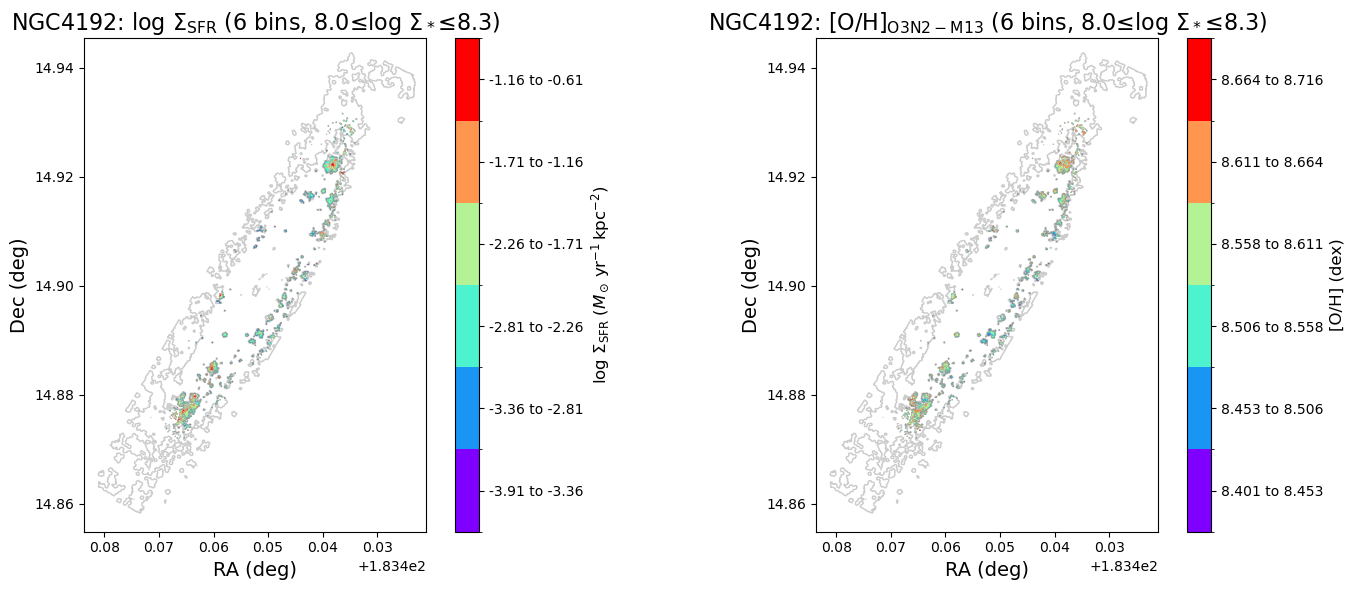

In [4]:
# ------------------------------------------------------------------
# 0.  Load NGC4192 maps and visualise Σ_SFR bins (6) + [O/H] bins (6, rainbow)
#     Highlight only spaxels with 8.0 ≤ log Σ_* ≤ 8.3; others appear as gray contours
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# Only focus on NGC4192 for this visualisation
galaxies = ['NGC4192']

# ------------------------------------------------------------------
# 1.  Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    return sigM, sigSFR, oh_map, indicator_name, wcs, gas_header

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name, wcs_full, gas_header = load_maps(gal)

    # Valid pixels across maps
    valid_mass = np.isfinite(sigM)
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_all = valid_mass & valid_sfr & valid_oh

    # Highlight only spaxels in the requested stellar mass surface density range
    mass_min, mass_max = 8.0, 8.3
    mass_filter = valid_mass & (sigM >= mass_min) & (sigM <= mass_max)
    galaxy_outline = valid_all

    total_valid = int(np.sum(galaxy_outline))
    highlighted = int(np.sum(mass_filter & galaxy_outline))
    print(f"Total valid spaxels for {gal}: {total_valid}")
    print(f"Spaxels with {mass_min:.1f} ≤ log Σ_* ≤ {mass_max:.1f}: {highlighted} ({highlighted/total_valid*100:.1f}% of valid spaxels)")

    if highlighted == 0:
        raise ValueError("No spaxels fall within the requested stellar-mass surface density range.")

    # ------------------------------------------------------------------
    # 2.  Define bin edges based on filtered spaxels
    # ------------------------------------------------------------------
    filtered_sfr = sigSFR[mass_filter & valid_sfr]
    filtered_oh = oh_o3n2_map[mass_filter & valid_oh]

    # Σ_SFR bins (6)
    n_sfr_bins = 6
    sfr_min, sfr_max = np.nanmin(filtered_sfr), np.nanmax(filtered_sfr)
    sfr_bin_edges = np.linspace(sfr_min, sfr_max, n_sfr_bins + 1)
    colors_sfr = plt.cm.rainbow(np.linspace(0, 1, n_sfr_bins))

    # Metallicities bins (6 equal width, rainbow palette)
    n_oh_bins = 6
    oh_min, oh_max = np.nanmin(filtered_oh), np.nanmax(filtered_oh)
    oh_bin_edges = np.linspace(oh_min, oh_max, n_oh_bins + 1)
    colors_oh = plt.cm.rainbow(np.linspace(0, 1, n_oh_bins))

    # ------------------------------------------------------------------
    # 3.  Prepare coordinate extent for plotting (RA/Dec degrees)
    # ------------------------------------------------------------------
    wcs_celestial = WCS(gas_header).celestial
    y_size, x_size = sigSFR.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]

    # ------------------------------------------------------------------
    # 4.  Build discrete maps for Σ_SFR bins (left) and [O/H] bins (right)
    #     Apply stellar-mass filter so only selected spaxels are coloured
    # ------------------------------------------------------------------
    sfr_bin_map = np.full(sigSFR.shape, np.nan)
    oh_bin_map = np.full(oh_o3n2_map.shape, np.nan)

    for i in range(n_sfr_bins):
        lower, upper = sfr_bin_edges[i], sfr_bin_edges[i + 1]
        if i == n_sfr_bins - 1:
            mask = mass_filter & valid_sfr & (sigSFR >= lower) & (sigSFR <= upper)
        else:
            mask = mass_filter & valid_sfr & (sigSFR >= lower) & (sigSFR < upper)
        sfr_bin_map[mask] = i

    for i in range(n_oh_bins):
        lower, upper = oh_bin_edges[i], oh_bin_edges[i + 1]
        if i == n_oh_bins - 1:
            mask = mass_filter & valid_oh & (oh_o3n2_map >= lower) & (oh_o3n2_map <= upper)
        else:
            mask = mass_filter & valid_oh & (oh_o3n2_map >= lower) & (oh_o3n2_map < upper)
        oh_bin_map[mask] = i

    # ------------------------------------------------------------------
    # 5.  Create figure: left = Σ_SFR bins, right = [O/H] bins (rainbow)
    # ------------------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Left-hand side: Σ_SFR bin map
    sfr_cmap = ListedColormap(colors_sfr)
    sfr_norm = BoundaryNorm(np.arange(-0.5, n_sfr_bins + 0.5, 1), n_sfr_bins)
    im_sfr = axes[0].imshow(np.ma.masked_invalid(sfr_bin_map), origin='lower', cmap=sfr_cmap,
                            norm=sfr_norm, extent=extent)
    axes[0].set_title(rf'{gal}: $\log\,\Sigma_{{\mathrm{{SFR}}}}$ (6 bins, {mass_min:.1f}≤$\log\,\Sigma_* $≤{mass_max:.1f})', fontsize=16)
    axes[0].set_xlabel('RA (deg)', fontsize=14)
    axes[0].set_ylabel('Dec (deg)', fontsize=14)

    cbar_sfr = fig.colorbar(im_sfr, ax=axes[0], fraction=0.046, pad=0.04)
    cbar_sfr.set_label(r'$\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
    sfr_tick_positions = np.arange(n_sfr_bins)
    sfr_tick_labels = [f'{sfr_bin_edges[i]:.2f} to {sfr_bin_edges[i+1]:.2f}' for i in range(n_sfr_bins)]
    cbar_sfr.set_ticks(sfr_tick_positions)
    cbar_sfr.set_ticklabels(sfr_tick_labels)

    # Right-hand side: [O/H] bin map (rainbow)
    oh_cmap = ListedColormap(colors_oh)
    oh_norm = BoundaryNorm(np.arange(-0.5, n_oh_bins + 0.5, 1), n_oh_bins)
    im_oh = axes[1].imshow(np.ma.masked_invalid(oh_bin_map), origin='lower', cmap=oh_cmap,
                           norm=oh_norm, extent=extent)
    axes[1].set_title(rf'{gal}: [O/H]$_{{\mathrm{{{indicator_name}}}}}$ (6 bins, {mass_min:.1f}≤$\log\,\Sigma_* $≤{mass_max:.1f})', fontsize=16)
    axes[1].set_xlabel('RA (deg)', fontsize=14)
    axes[1].set_ylabel('Dec (deg)', fontsize=14)

    cbar_oh = fig.colorbar(im_oh, ax=axes[1], fraction=0.046, pad=0.04)
    cbar_oh.set_label(r'[O/H] (dex)', fontsize=12)
    oh_tick_positions = np.arange(n_oh_bins)
    oh_tick_labels = [f'{oh_bin_edges[i]:.3f} to {oh_bin_edges[i+1]:.3f}' for i in range(n_oh_bins)]
    cbar_oh.set_ticks(oh_tick_positions)
    cbar_oh.set_ticklabels(oh_tick_labels)

    # Add gray contour to indicate the full galaxy footprint
    galaxy_mask_float = galaxy_outline.astype(float)
    for ax in axes:
        ax.contour(ra, dec, galaxy_mask_float, levels=[0.5], colors='gray', linewidths=1,
                   linestyles='-', origin='lower', alpha=0.4)

    # For reporting: median [O/H] per metallicity bin (over highlighted pixels only)
    print(f"\n[{indicator_name}] [O/H] statistics by metallicity bin for {gal} (mass filtered):")
    for i in range(n_oh_bins):
        bin_mask = (oh_bin_map == i) & mass_filter & valid_all
        n_pixels = int(np.sum(bin_mask))
        if n_pixels > 0:
            median_oh = np.nanmedian(oh_o3n2_map[bin_mask])
            print(f"  Bin {i+1} ({oh_bin_edges[i]:.3f} to {oh_bin_edges[i+1]:.3f}): {n_pixels} pixels, median [O/H] = {median_oh:.3f}")
        else:
            print(f"  Bin {i+1} ({oh_bin_edges[i]:.3f} to {oh_bin_edges[i+1]:.3f}): 0 pixels")

    plt.tight_layout()
    # plt.savefig(f'{gal}_SigmaSFR_and_OH_maps_mass_filtered.png', dpi=600)
    plt.show()

Total valid spaxels for NGC4192: 145944
Spaxels with 8.0 ≤ log Σ_* ≤ 8.3: 16512 (11.3% of valid spaxels)

[O3N2-M13] [O/H] statistics by metallicity bin for NGC4192 (mass filtered):
  Bin 1 (8.401 to 8.506): 1166 pixels, median [O/H] = 8.491
  Bin 2 (8.506 to 8.611): 12711 pixels, median [O/H] = 8.566
  Bin 3 (8.611 to 8.716): 2635 pixels, median [O/H] = 8.625


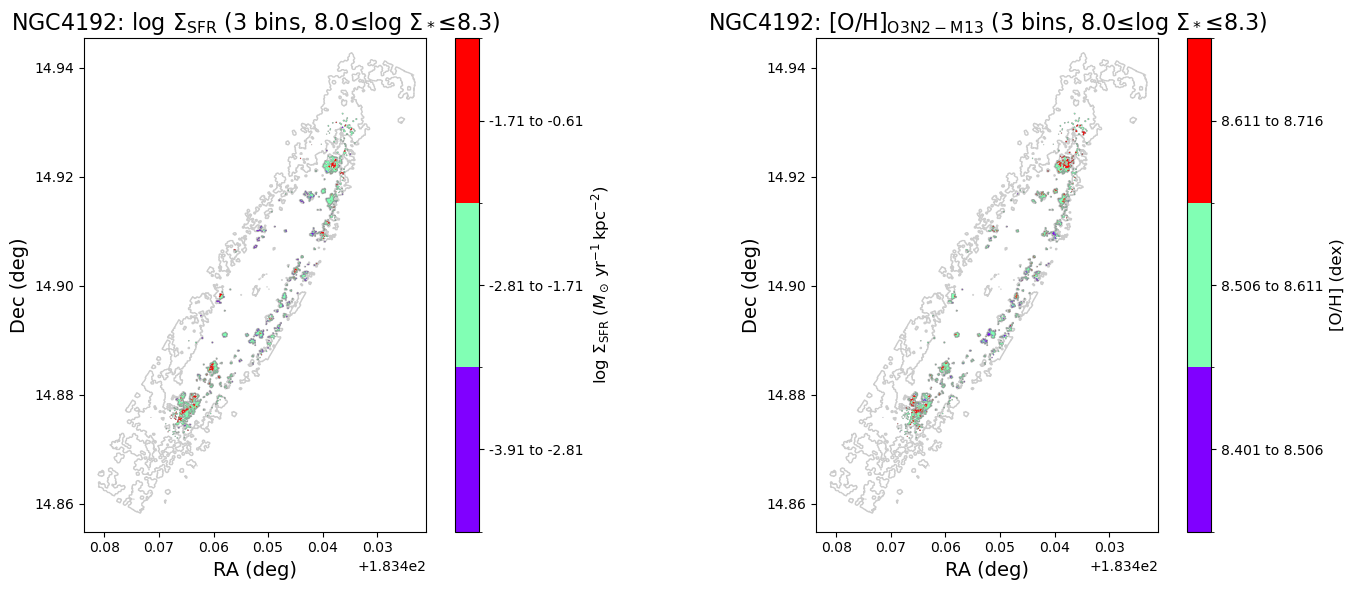

In [5]:
# ------------------------------------------------------------------
# 0.  Load NGC4192 maps and visualise Σ_SFR bins (3) + [O/H] bins (3, rainbow)
#     Highlight only spaxels with 8.0 ≤ log Σ_* ≤ 8.3; others appear as gray contours
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# Only focus on NGC4192 for this visualisation
galaxies = ['NGC4192']

# ------------------------------------------------------------------
# 1.  Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    return sigM, sigSFR, oh_map, indicator_name, wcs, gas_header

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name, wcs_full, gas_header = load_maps(gal)

    # Valid pixels across maps
    valid_mass = np.isfinite(sigM)
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_all = valid_mass & valid_sfr & valid_oh

    # Highlight only spaxels in the requested stellar mass surface density range
    mass_min, mass_max = 8.0, 8.3
    mass_filter = valid_mass & (sigM >= mass_min) & (sigM <= mass_max)
    galaxy_outline = valid_all

    total_valid = int(np.sum(galaxy_outline))
    highlighted = int(np.sum(mass_filter & galaxy_outline))
    print(f"Total valid spaxels for {gal}: {total_valid}")
    print(f"Spaxels with {mass_min:.1f} ≤ log Σ_* ≤ {mass_max:.1f}: {highlighted} ({highlighted/total_valid*100:.1f}% of valid spaxels)")

    if highlighted == 0:
        raise ValueError("No spaxels fall within the requested stellar-mass surface density range.")

    # ------------------------------------------------------------------
    # 2.  Define bin edges based on filtered spaxels
    # ------------------------------------------------------------------
    filtered_sfr = sigSFR[mass_filter & valid_sfr]
    filtered_oh = oh_o3n2_map[mass_filter & valid_oh]

    # Σ_SFR bins (3)
    n_sfr_bins = 3
    sfr_min, sfr_max = np.nanmin(filtered_sfr), np.nanmax(filtered_sfr)
    sfr_bin_edges = np.linspace(sfr_min, sfr_max, n_sfr_bins + 1)
    colors_sfr = plt.cm.rainbow(np.linspace(0, 1, n_sfr_bins))

    # Metallicities bins (3 equal width, rainbow palette)
    n_oh_bins = 3
    oh_min, oh_max = np.nanmin(filtered_oh), np.nanmax(filtered_oh)
    oh_bin_edges = np.linspace(oh_min, oh_max, n_oh_bins + 1)
    colors_oh = plt.cm.rainbow(np.linspace(0, 1, n_oh_bins))

    # ------------------------------------------------------------------
    # 3.  Prepare coordinate extent for plotting (RA/Dec degrees)
    # ------------------------------------------------------------------
    wcs_celestial = WCS(gas_header).celestial
    y_size, x_size = sigSFR.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]

    # ------------------------------------------------------------------
    # 4.  Build discrete maps for Σ_SFR bins (left) and [O/H] bins (right)
    #     Apply stellar-mass filter so only selected spaxels are coloured
    # ------------------------------------------------------------------
    sfr_bin_map = np.full(sigSFR.shape, np.nan)
    oh_bin_map = np.full(oh_o3n2_map.shape, np.nan)

    for i in range(n_sfr_bins):
        lower, upper = sfr_bin_edges[i], sfr_bin_edges[i + 1]
        if i == n_sfr_bins - 1:
            mask = mass_filter & valid_sfr & (sigSFR >= lower) & (sigSFR <= upper)
        else:
            mask = mass_filter & valid_sfr & (sigSFR >= lower) & (sigSFR < upper)
        sfr_bin_map[mask] = i

    for i in range(n_oh_bins):
        lower, upper = oh_bin_edges[i], oh_bin_edges[i + 1]
        if i == n_oh_bins - 1:
            mask = mass_filter & valid_oh & (oh_o3n2_map >= lower) & (oh_o3n2_map <= upper)
        else:
            mask = mass_filter & valid_oh & (oh_o3n2_map >= lower) & (oh_o3n2_map < upper)
        oh_bin_map[mask] = i

    # ------------------------------------------------------------------
    # 5.  Create figure: left = Σ_SFR bins, right = [O/H] bins (rainbow)
    # ------------------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Left-hand side: Σ_SFR bin map
    sfr_cmap = ListedColormap(colors_sfr)
    sfr_norm = BoundaryNorm(np.arange(-0.5, n_sfr_bins + 0.5, 1), n_sfr_bins)
    im_sfr = axes[0].imshow(np.ma.masked_invalid(sfr_bin_map), origin='lower', cmap=sfr_cmap,
                            norm=sfr_norm, extent=extent)
    axes[0].set_title(rf'{gal}: $\log\,\Sigma_{{\mathrm{{SFR}}}}$ (3 bins, {mass_min:.1f}≤$\log\,\Sigma_* $≤{mass_max:.1f})', fontsize=16)
    axes[0].set_xlabel('RA (deg)', fontsize=14)
    axes[0].set_ylabel('Dec (deg)', fontsize=14)

    cbar_sfr = fig.colorbar(im_sfr, ax=axes[0], fraction=0.046, pad=0.04)
    cbar_sfr.set_label(r'$\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
    sfr_tick_positions = np.arange(n_sfr_bins)
    sfr_tick_labels = [f'{sfr_bin_edges[i]:.2f} to {sfr_bin_edges[i+1]:.2f}' for i in range(n_sfr_bins)]
    cbar_sfr.set_ticks(sfr_tick_positions)
    cbar_sfr.set_ticklabels(sfr_tick_labels)

    # Right-hand side: [O/H] bin map (rainbow)
    oh_cmap = ListedColormap(colors_oh)
    oh_norm = BoundaryNorm(np.arange(-0.5, n_oh_bins + 0.5, 1), n_oh_bins)
    im_oh = axes[1].imshow(np.ma.masked_invalid(oh_bin_map), origin='lower', cmap=oh_cmap,
                           norm=oh_norm, extent=extent)
    axes[1].set_title(rf'{gal}: [O/H]$_{{\mathrm{{{indicator_name}}}}}$ (3 bins, {mass_min:.1f}≤$\log\,\Sigma_* $≤{mass_max:.1f})', fontsize=16)
    axes[1].set_xlabel('RA (deg)', fontsize=14)
    axes[1].set_ylabel('Dec (deg)', fontsize=14)

    cbar_oh = fig.colorbar(im_oh, ax=axes[1], fraction=0.046, pad=0.04)
    cbar_oh.set_label(r'[O/H] (dex)', fontsize=12)
    oh_tick_positions = np.arange(n_oh_bins)
    oh_tick_labels = [f'{oh_bin_edges[i]:.3f} to {oh_bin_edges[i+1]:.3f}' for i in range(n_oh_bins)]
    cbar_oh.set_ticks(oh_tick_positions)
    cbar_oh.set_ticklabels(oh_tick_labels)

    # Add gray contour to indicate the full galaxy footprint
    galaxy_mask_float = galaxy_outline.astype(float)
    for ax in axes:
        ax.contour(ra, dec, galaxy_mask_float, levels=[0.5], colors='gray', linewidths=1,
                   linestyles='-', origin='lower', alpha=0.4)

    # For reporting: median [O/H] per metallicity bin (over highlighted pixels only)
    print(f"\n[{indicator_name}] [O/H] statistics by metallicity bin for {gal} (mass filtered):")
    for i in range(n_oh_bins):
        bin_mask = (oh_bin_map == i) & mass_filter & valid_all
        n_pixels = int(np.sum(bin_mask))
        if n_pixels > 0:
            median_oh = np.nanmedian(oh_o3n2_map[bin_mask])
            print(f"  Bin {i+1} ({oh_bin_edges[i]:.3f} to {oh_bin_edges[i+1]:.3f}): {n_pixels} pixels, median [O/H] = {median_oh:.3f}")
        else:
            print(f"  Bin {i+1} ({oh_bin_edges[i]:.3f} to {oh_bin_edges[i+1]:.3f}): 0 pixels")

    plt.tight_layout()
    # plt.savefig(f'{gal}_SigmaSFR_and_OH_maps_mass_filtered.png', dpi=600)
    plt.show()

## 20251010 Define two regimes that show definitely monotomic correlation between $Z_\mathrm{gas}$ and $\Sigma_\mathrm{SFR}$
1. inverse correlation (low mass, low SFR end): $\Sigma_*<7.6$ & $-3.5<\Sigma_\mathrm{SFR}<-2$
2. correlation (high mass, high SFR end): $\Sigma_*>7.8$ & $\Sigma_\mathrm{SFR}>-2$

Total valid spaxels for NGC4192: 145944
Spaxels with log Σ_* < 7.6 and -3.5 < log Σ_SFR < -2.0: 51279 (35.1% of valid spaxels)

[O3N2-M13] [O/H] statistics by metallicity bin for NGC4192 (filtered):
  Bin 1 (8.398 to 8.447): 962 pixels, median [O/H] = 8.432
  Bin 2 (8.447 to 8.496): 4562 pixels, median [O/H] = 8.479
  Bin 3 (8.496 to 8.545): 15911 pixels, median [O/H] = 8.525
  Bin 4 (8.545 to 8.594): 22146 pixels, median [O/H] = 8.567
  Bin 5 (8.594 to 8.643): 6964 pixels, median [O/H] = 8.606
  Bin 6 (8.643 to 8.692): 734 pixels, median [O/H] = 8.659


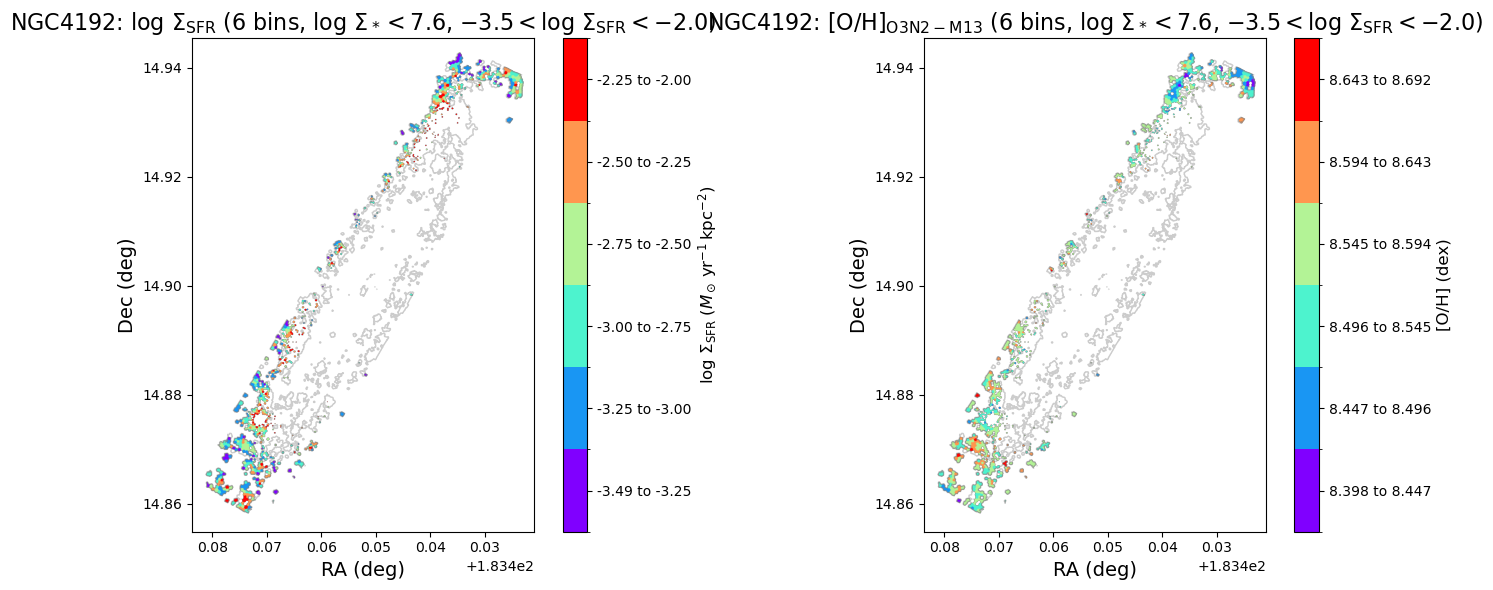

In [1]:
# ------------------------------------------------------------------
# 0.  Load NGC4192 maps and visualise Σ_SFR bins (6) + [O/H] bins (6, rainbow)
#     Highlight only spaxels with Σ_* < 7.6 and -3.5 < Σ_SFR < -2; others appear as gray contours
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# Only focus on NGC4192 for this visualisation
galaxies = ['NGC4192']

# ------------------------------------------------------------------
# 1.  Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    return sigM, sigSFR, oh_map, indicator_name, wcs, gas_header

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name, wcs_full, gas_header = load_maps(gal)

    # Valid pixels across maps
    valid_mass = np.isfinite(sigM)
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_all = valid_mass & valid_sfr & valid_oh

    # Apply filter criteria: Σ_* < 7.6 and -3.5 < Σ_SFR < -2
    mass_max = 7.6
    sfr_min, sfr_max = -3.5, -2.0
    mass_filter = valid_mass & (sigM < mass_max)
    sfr_filter = valid_sfr & (sigSFR > sfr_min) & (sigSFR < sfr_max)
    combined_filter = mass_filter & sfr_filter & valid_all
    galaxy_outline = valid_all

    total_valid = int(np.sum(galaxy_outline))
    highlighted = int(np.sum(combined_filter))
    print(f"Total valid spaxels for {gal}: {total_valid}")
    print(f"Spaxels with log Σ_* < {mass_max:.1f} and {sfr_min:.1f} < log Σ_SFR < {sfr_max:.1f}: {highlighted} ({highlighted/total_valid*100:.1f}% of valid spaxels)")

    if highlighted == 0:
        raise ValueError("No spaxels fall within the requested filter criteria.")

    # ------------------------------------------------------------------
    # 2.  Define bin edges based on filtered spaxels
    # ------------------------------------------------------------------
    filtered_sfr = sigSFR[combined_filter]
    filtered_oh = oh_o3n2_map[combined_filter]

    # Σ_SFR bins (6)
    n_sfr_bins = 6
    sfr_data_min, sfr_data_max = np.nanmin(filtered_sfr), np.nanmax(filtered_sfr)
    sfr_bin_edges = np.linspace(sfr_data_min, sfr_data_max, n_sfr_bins + 1)
    colors_sfr = plt.cm.rainbow(np.linspace(0, 1, n_sfr_bins))

    # Metallicities bins (6 equal width, rainbow palette)
    n_oh_bins = 6
    oh_min, oh_max = np.nanmin(filtered_oh), np.nanmax(filtered_oh)
    oh_bin_edges = np.linspace(oh_min, oh_max, n_oh_bins + 1)
    colors_oh = plt.cm.rainbow(np.linspace(0, 1, n_oh_bins))

    # ------------------------------------------------------------------
    # 3.  Prepare coordinate extent for plotting (RA/Dec degrees)
    # ------------------------------------------------------------------
    wcs_celestial = WCS(gas_header).celestial
    y_size, x_size = sigSFR.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]

    # ------------------------------------------------------------------
    # 4.  Build discrete maps for Σ_SFR bins (left) and [O/H] bins (right)
    #     Apply combined filter so only selected spaxels are coloured
    # ------------------------------------------------------------------
    sfr_bin_map = np.full(sigSFR.shape, np.nan)
    oh_bin_map = np.full(oh_o3n2_map.shape, np.nan)

    for i in range(n_sfr_bins):
        lower, upper = sfr_bin_edges[i], sfr_bin_edges[i + 1]
        if i == n_sfr_bins - 1:
            mask = combined_filter & (sigSFR >= lower) & (sigSFR <= upper)
        else:
            mask = combined_filter & (sigSFR >= lower) & (sigSFR < upper)
        sfr_bin_map[mask] = i

    for i in range(n_oh_bins):
        lower, upper = oh_bin_edges[i], oh_bin_edges[i + 1]
        if i == n_oh_bins - 1:
            mask = combined_filter & (oh_o3n2_map >= lower) & (oh_o3n2_map <= upper)
        else:
            mask = combined_filter & (oh_o3n2_map >= lower) & (oh_o3n2_map < upper)
        oh_bin_map[mask] = i

    # ------------------------------------------------------------------
    # 5.  Create figure: left = Σ_SFR bins, right = [O/H] bins (rainbow)
    # ------------------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Left-hand side: Σ_SFR bin map
    sfr_cmap = ListedColormap(colors_sfr)
    sfr_norm = BoundaryNorm(np.arange(-0.5, n_sfr_bins + 0.5, 1), n_sfr_bins)
    im_sfr = axes[0].imshow(np.ma.masked_invalid(sfr_bin_map), origin='lower', cmap=sfr_cmap,
                            norm=sfr_norm, extent=extent)
    axes[0].set_title(rf'{gal}: $\log\,\Sigma_{{\mathrm{{SFR}}}}$ (6 bins, $\log\,\Sigma_* <{mass_max:.1f}$, ${sfr_min:.1f}<\log\,\Sigma_{{\mathrm{{SFR}}}}<{sfr_max:.1f}$)', fontsize=16)
    axes[0].set_xlabel('RA (deg)', fontsize=14)
    axes[0].set_ylabel('Dec (deg)', fontsize=14)

    cbar_sfr = fig.colorbar(im_sfr, ax=axes[0], fraction=0.046, pad=0.04)
    cbar_sfr.set_label(r'$\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
    sfr_tick_positions = np.arange(n_sfr_bins)
    sfr_tick_labels = [f'{sfr_bin_edges[i]:.2f} to {sfr_bin_edges[i+1]:.2f}' for i in range(n_sfr_bins)]
    cbar_sfr.set_ticks(sfr_tick_positions)
    cbar_sfr.set_ticklabels(sfr_tick_labels)

    # Right-hand side: [O/H] bin map (rainbow)
    oh_cmap = ListedColormap(colors_oh)
    oh_norm = BoundaryNorm(np.arange(-0.5, n_oh_bins + 0.5, 1), n_oh_bins)
    im_oh = axes[1].imshow(np.ma.masked_invalid(oh_bin_map), origin='lower', cmap=oh_cmap,
                           norm=oh_norm, extent=extent)
    axes[1].set_title(rf'{gal}: [O/H]$_{{\mathrm{{{indicator_name}}}}}$ (6 bins, $\log\,\Sigma_* <{mass_max:.1f}$, ${sfr_min:.1f}<\log\,\Sigma_{{\mathrm{{SFR}}}}<{sfr_max:.1f}$)', fontsize=16)
    axes[1].set_xlabel('RA (deg)', fontsize=14)
    axes[1].set_ylabel('Dec (deg)', fontsize=14)

    cbar_oh = fig.colorbar(im_oh, ax=axes[1], fraction=0.046, pad=0.04)
    cbar_oh.set_label(r'[O/H] (dex)', fontsize=12)
    oh_tick_positions = np.arange(n_oh_bins)
    oh_tick_labels = [f'{oh_bin_edges[i]:.3f} to {oh_bin_edges[i+1]:.3f}' for i in range(n_oh_bins)]
    cbar_oh.set_ticks(oh_tick_positions)
    cbar_oh.set_ticklabels(oh_tick_labels)

    # Add gray contour to indicate the full galaxy footprint
    galaxy_mask_float = galaxy_outline.astype(float)
    for ax in axes:
        ax.contour(ra, dec, galaxy_mask_float, levels=[0.5], colors='gray', linewidths=1,
                   linestyles='-', origin='lower', alpha=0.4)

    # For reporting: median [O/H] per metallicity bin (over highlighted pixels only)
    print(f"\n[{indicator_name}] [O/H] statistics by metallicity bin for {gal} (filtered):")
    for i in range(n_oh_bins):
        bin_mask = (oh_bin_map == i) & combined_filter
        n_pixels = int(np.sum(bin_mask))
        if n_pixels > 0:
            median_oh = np.nanmedian(oh_o3n2_map[bin_mask])
            print(f"  Bin {i+1} ({oh_bin_edges[i]:.3f} to {oh_bin_edges[i+1]:.3f}): {n_pixels} pixels, median [O/H] = {median_oh:.3f}")
        else:
            print(f"  Bin {i+1} ({oh_bin_edges[i]:.3f} to {oh_bin_edges[i+1]:.3f}): 0 pixels")

    plt.tight_layout()
    # plt.savefig(f'{gal}_SigmaSFR_and_OH_maps_mass_filtered.png', dpi=600)
    plt.show()

Total valid spaxels for NGC4192: 145944
Spaxels with log Σ_* > 7.8 and log Σ_SFR > -2.0: 12736 (8.7% of valid spaxels)

[O3N2-M13] [O/H] statistics by metallicity bin for NGC4192 (filtered):
  Bin 1 (8.413 to 8.498): 582 pixels, median [O/H] = 8.484
  Bin 2 (8.498 to 8.582): 7141 pixels, median [O/H] = 8.559
  Bin 3 (8.582 to 8.666): 4962 pixels, median [O/H] = 8.604
  Bin 4 (8.666 to 8.750): 41 pixels, median [O/H] = 8.686
  Bin 5 (8.750 to 8.834): 8 pixels, median [O/H] = 8.802
  Bin 6 (8.834 to 8.918): 2 pixels, median [O/H] = 8.918


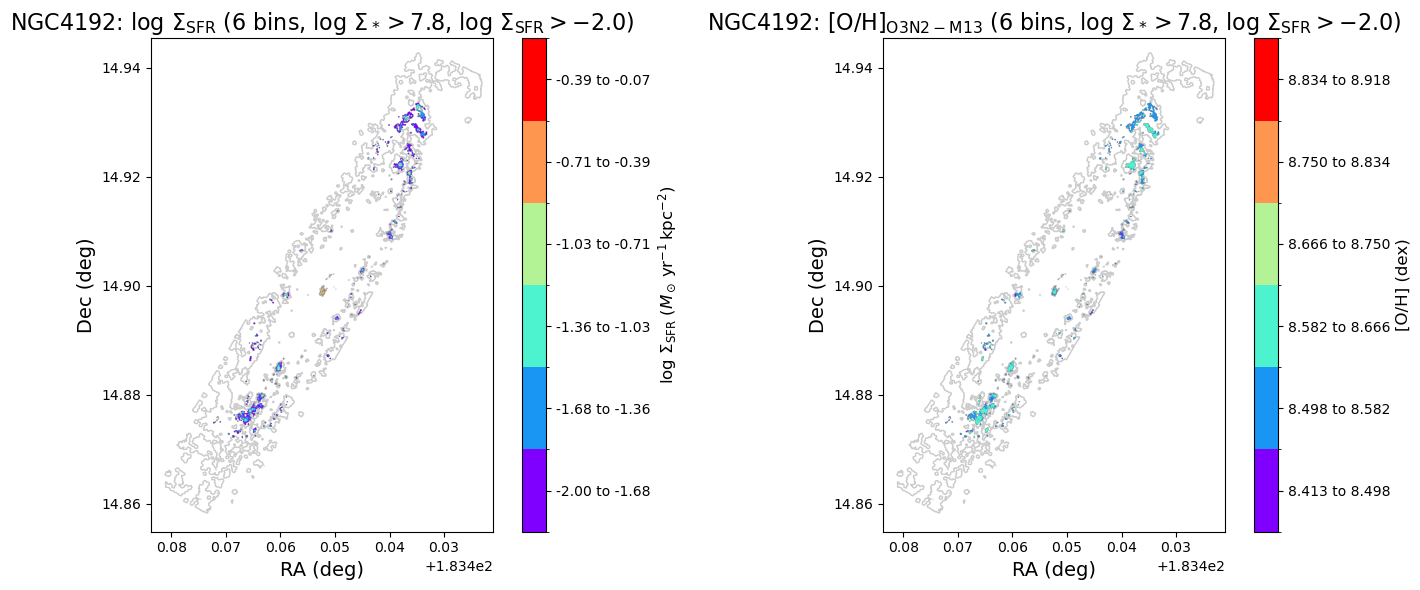

In [2]:
# ------------------------------------------------------------------
# 0.  Load NGC4192 maps and visualise Σ_SFR bins (6) + [O/H] bins (6, rainbow)
#     Highlight only spaxels with Σ_* > 7.8 and Σ_SFR > -2; others appear as gray contours
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# Only focus on NGC4192 for this visualisation
galaxies = ['NGC4192']

# ------------------------------------------------------------------
# 1.  Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    return sigM, sigSFR, oh_map, indicator_name, wcs, gas_header

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name, wcs_full, gas_header = load_maps(gal)

    # Valid pixels across maps
    valid_mass = np.isfinite(sigM)
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_all = valid_mass & valid_sfr & valid_oh

    # Apply filter criteria: Σ_* > 7.8 and Σ_SFR > -2
    mass_min = 7.8
    sfr_min = -2.0
    mass_filter = valid_mass & (sigM > mass_min)
    sfr_filter = valid_sfr & (sigSFR > sfr_min)
    combined_filter = mass_filter & sfr_filter & valid_all
    galaxy_outline = valid_all

    total_valid = int(np.sum(galaxy_outline))
    highlighted = int(np.sum(combined_filter))
    print(f"Total valid spaxels for {gal}: {total_valid}")
    print(f"Spaxels with log Σ_* > {mass_min:.1f} and log Σ_SFR > {sfr_min:.1f}: {highlighted} ({highlighted/total_valid*100:.1f}% of valid spaxels)")

    if highlighted == 0:
        raise ValueError("No spaxels fall within the requested filter criteria.")

    # ------------------------------------------------------------------
    # 2.  Define bin edges based on filtered spaxels
    # ------------------------------------------------------------------
    filtered_sfr = sigSFR[combined_filter]
    filtered_oh = oh_o3n2_map[combined_filter]

    # Σ_SFR bins (6)
    n_sfr_bins = 6
    sfr_data_min, sfr_data_max = np.nanmin(filtered_sfr), np.nanmax(filtered_sfr)
    sfr_bin_edges = np.linspace(sfr_data_min, sfr_data_max, n_sfr_bins + 1)
    colors_sfr = plt.cm.rainbow(np.linspace(0, 1, n_sfr_bins))

    # Metallicities bins (6 equal width, rainbow palette)
    n_oh_bins = 6
    oh_min, oh_max = np.nanmin(filtered_oh), np.nanmax(filtered_oh)
    oh_bin_edges = np.linspace(oh_min, oh_max, n_oh_bins + 1)
    colors_oh = plt.cm.rainbow(np.linspace(0, 1, n_oh_bins))

    # ------------------------------------------------------------------
    # 3.  Prepare coordinate extent for plotting (RA/Dec degrees)
    # ------------------------------------------------------------------
    wcs_celestial = WCS(gas_header).celestial
    y_size, x_size = sigSFR.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]

    # ------------------------------------------------------------------
    # 4.  Build discrete maps for Σ_SFR bins (left) and [O/H] bins (right)
    #     Apply combined filter so only selected spaxels are coloured
    # ------------------------------------------------------------------
    sfr_bin_map = np.full(sigSFR.shape, np.nan)
    oh_bin_map = np.full(oh_o3n2_map.shape, np.nan)

    for i in range(n_sfr_bins):
        lower, upper = sfr_bin_edges[i], sfr_bin_edges[i + 1]
        if i == n_sfr_bins - 1:
            mask = combined_filter & (sigSFR >= lower) & (sigSFR <= upper)
        else:
            mask = combined_filter & (sigSFR >= lower) & (sigSFR < upper)
        sfr_bin_map[mask] = i

    for i in range(n_oh_bins):
        lower, upper = oh_bin_edges[i], oh_bin_edges[i + 1]
        if i == n_oh_bins - 1:
            mask = combined_filter & (oh_o3n2_map >= lower) & (oh_o3n2_map <= upper)
        else:
            mask = combined_filter & (oh_o3n2_map >= lower) & (oh_o3n2_map < upper)
        oh_bin_map[mask] = i

    # ------------------------------------------------------------------
    # 5.  Create figure: left = Σ_SFR bins, right = [O/H] bins (rainbow)
    # ------------------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Left-hand side: Σ_SFR bin map
    sfr_cmap = ListedColormap(colors_sfr)
    sfr_norm = BoundaryNorm(np.arange(-0.5, n_sfr_bins + 0.5, 1), n_sfr_bins)
    im_sfr = axes[0].imshow(np.ma.masked_invalid(sfr_bin_map), origin='lower', cmap=sfr_cmap,
                            norm=sfr_norm, extent=extent)
    axes[0].set_title(rf'{gal}: $\log\,\Sigma_{{\mathrm{{SFR}}}}$ (6 bins, $\log\,\Sigma_* >{mass_min:.1f}$, $\log\,\Sigma_{{\mathrm{{SFR}}}}>{sfr_min:.1f}$)', fontsize=16)
    axes[0].set_xlabel('RA (deg)', fontsize=14)
    axes[0].set_ylabel('Dec (deg)', fontsize=14)

    cbar_sfr = fig.colorbar(im_sfr, ax=axes[0], fraction=0.046, pad=0.04)
    cbar_sfr.set_label(r'$\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
    sfr_tick_positions = np.arange(n_sfr_bins)
    sfr_tick_labels = [f'{sfr_bin_edges[i]:.2f} to {sfr_bin_edges[i+1]:.2f}' for i in range(n_sfr_bins)]
    cbar_sfr.set_ticks(sfr_tick_positions)
    cbar_sfr.set_ticklabels(sfr_tick_labels)

    # Right-hand side: [O/H] bin map (rainbow)
    oh_cmap = ListedColormap(colors_oh)
    oh_norm = BoundaryNorm(np.arange(-0.5, n_oh_bins + 0.5, 1), n_oh_bins)
    im_oh = axes[1].imshow(np.ma.masked_invalid(oh_bin_map), origin='lower', cmap=oh_cmap,
                           norm=oh_norm, extent=extent)
    axes[1].set_title(rf'{gal}: [O/H]$_{{\mathrm{{{indicator_name}}}}}$ (6 bins, $\log\,\Sigma_* >{mass_min:.1f}$, $\log\,\Sigma_{{\mathrm{{SFR}}}}>{sfr_min:.1f}$)', fontsize=16)
    axes[1].set_xlabel('RA (deg)', fontsize=14)
    axes[1].set_ylabel('Dec (deg)', fontsize=14)

    cbar_oh = fig.colorbar(im_oh, ax=axes[1], fraction=0.046, pad=0.04)
    cbar_oh.set_label(r'[O/H] (dex)', fontsize=12)
    oh_tick_positions = np.arange(n_oh_bins)
    oh_tick_labels = [f'{oh_bin_edges[i]:.3f} to {oh_bin_edges[i+1]:.3f}' for i in range(n_oh_bins)]
    cbar_oh.set_ticks(oh_tick_positions)
    cbar_oh.set_ticklabels(oh_tick_labels)

    # Add gray contour to indicate the full galaxy footprint
    galaxy_mask_float = galaxy_outline.astype(float)
    for ax in axes:
        ax.contour(ra, dec, galaxy_mask_float, levels=[0.5], colors='gray', linewidths=1,
                   linestyles='-', origin='lower', alpha=0.4)

    # For reporting: median [O/H] per metallicity bin (over highlighted pixels only)
    print(f"\n[{indicator_name}] [O/H] statistics by metallicity bin for {gal} (filtered):")
    for i in range(n_oh_bins):
        bin_mask = (oh_bin_map == i) & combined_filter
        n_pixels = int(np.sum(bin_mask))
        if n_pixels > 0:
            median_oh = np.nanmedian(oh_o3n2_map[bin_mask])
            print(f"  Bin {i+1} ({oh_bin_edges[i]:.3f} to {oh_bin_edges[i+1]:.3f}): {n_pixels} pixels, median [O/H] = {median_oh:.3f}")
        else:
            print(f"  Bin {i+1} ({oh_bin_edges[i]:.3f} to {oh_bin_edges[i+1]:.3f}): 0 pixels")

    plt.tight_layout()
    # plt.savefig(f'{gal}_SigmaSFR_and_OH_maps_mass_filtered.png', dpi=600)
    plt.show()